<a href="https://colab.research.google.com/github/NehaSusan14/6THSEM-ML-LAB/blob/main/1BM23CS210_LAB9-KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

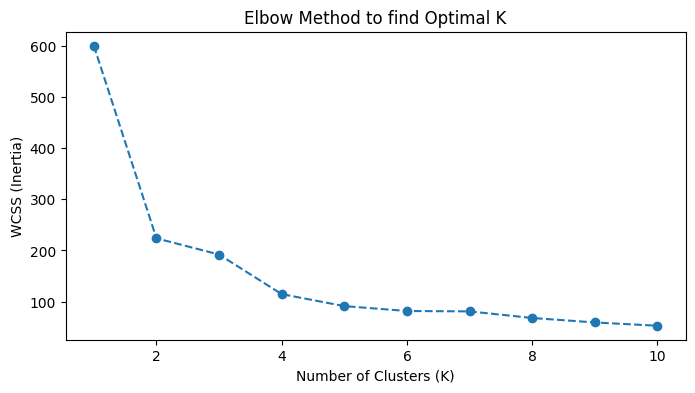

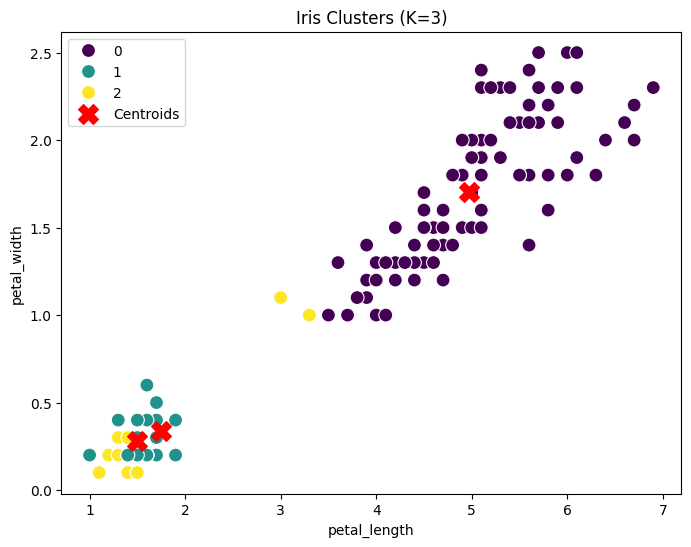

Clustering Complete. The labels have been added to the dataframe.
   sepal_length  sepal_width  petal_length  petal_width      species  \
0           5.1          3.5           1.4          0.2  Iris-setosa   
1           4.9          3.0           1.4          0.2  Iris-setosa   
2           4.7          3.2           1.3          0.2  Iris-setosa   
3           4.6          3.1           1.5          0.2  Iris-setosa   
4           5.0          3.6           1.4          0.2  Iris-setosa   

   cluster_labels  
0               1  
1               2  
2               2  
3               2  
4               1  


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
# Ensure the file 'iris (2).csv' is in your working directory
df = pd.read_csv('iris (2).csv')

# 2. Select the numeric features for clustering
# We drop 'species' because K-Means is an unsupervised algorithm
X = df.drop('species', axis=1)

# 3. Scale the features
# K-Means is distance-based, so scaling ensures all features contribute equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- TASK 1: Find the Optimal 'K' (Elbow Method) ---
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.show()

# --- TASK 2: Build the Final K-Means Model ---
# From the elbow plot (and knowledge of Iris), we choose K=3
final_kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster_labels'] = final_kmeans.fit_predict(X_scaled)

# 4. Visualize the Clusters
# Using Petal Length vs Petal Width for the clearest separation
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='cluster_labels', palette='viridis', s=100)

# Plot the cluster centers (centroids)
centroids = scaler.inverse_transform(final_kmeans.cluster_centers_)
plt.scatter(centroids[:, 2], centroids[:, 3], c='red', s=200, marker='X', label='Centroids')

plt.title('Iris Clusters (K=3)')
plt.legend()
plt.show()

print("Clustering Complete. The labels have been added to the dataframe.")
print(df.head())
